# BH-Binaries Channel Formation

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

In [25]:
load = np.load("../Solutions/formationchannels.npy")

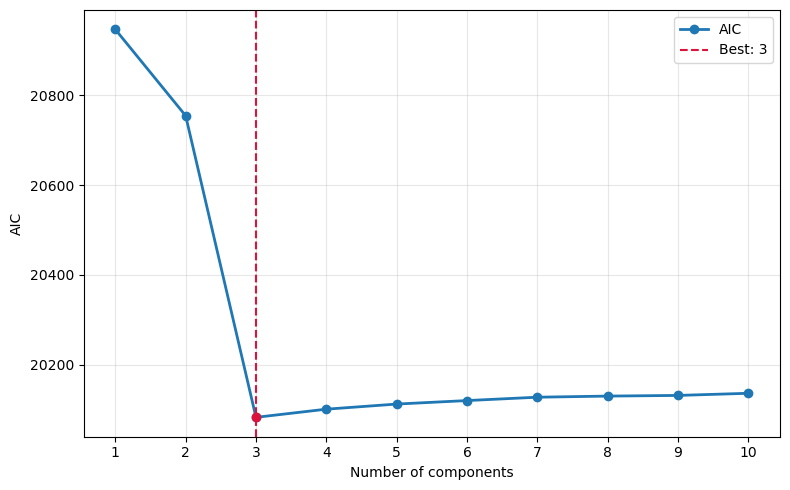

In [26]:
N = 10

x = load if load.ndim == 2 else load.reshape(-1, 1)
aic = np.zeros(N)

for n in range(N):
    gmm = GaussianMixture(n_components=n + 1, covariance_type='full', random_state=42)
    gmm.fit(x)
    aic[n] = gmm.aic(x)


components = np.arange(1, N + 1)
best = components[np.argmin(aic)]

plt.figure(figsize=(8, 5))
plt.plot(components, aic, marker='o', linewidth=2, label='AIC')
plt.axvline(best, color='crimson', linestyle='--', linewidth=1.5, label=f'Best: {best}')
plt.scatter(best, aic[best - 1], color='crimson', zorder=3)

plt.xticks(components)
plt.xlabel("Number of components")
plt.ylabel("AIC")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

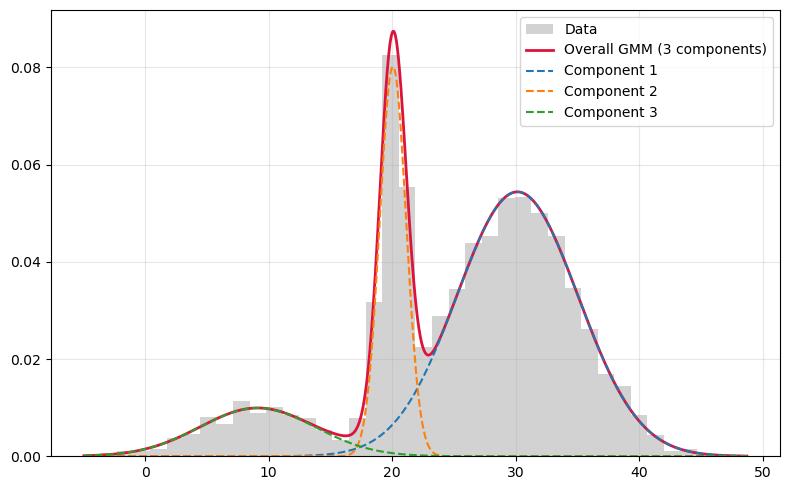

In [27]:
gmm_best = GaussianMixture(n_components=int(best), covariance_type='full', random_state=42)
gmm_best.fit(x)

xx = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm_best.score_samples(xx)) # GMM works with logs
components_pdf = np.zeros((len(xx), int(best)))
for k in range(int(best)):
    mu = np.ravel(gmm_best.means_[k])[0]
    var = np.squeeze(gmm_best.covariances_[k])
    sigma = np.sqrt(var)
    components_pdf[:, k] = gmm_best.weights_[k] * (1.0 / (np.sqrt(2 * np.pi) * sigma)) * \
                           np.exp(-0.5 * ((xx.ravel() - mu) / sigma) ** 2)

plt.figure(figsize=(8, 5))
plt.hist(x.ravel(), bins=40, density=True, alpha=0.35, color='gray', label='Data')
plt.plot(xx, pdf, color='crimson', linewidth=2, label=f'Overall GMM ({best} components)')

for k in range(int(best)):
    plt.plot(xx, components_pdf[:, k], '--', linewidth=1.5, label=f'Component {k+1}')

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()